# 预备课 4：降维与自动编码器 (Dimensionality Reduction & Autoencoders)

## 第一部分：维度与潜在空间 (Latent Space)

在真实的科学与工程任务中，传感器阵列采集的数据往往呈现极高的维度。例如，一段持续数秒的机械臂高频震动信号，或者天体物理中的高分辨率光谱，通常包含成百上千个数据点（维度）。

然而，这些高维表象下通常隐藏着低维的**本征物理自由度（Intrinsic Degrees of Freedom）**。

### 1. 维度灾难 (Curse of Dimensionality)
在机器学习中，随着特征维度的增加，样本空间的体积呈指数级膨胀，导致数据在空间中变得极其稀疏。直接处理高维数据不仅会引发算力爆炸，更容易导致模型陷入严重的过拟合。因此，**降维（Dimensionality Reduction）**是科学计算中不可或缺的预处理范式。

### 2. 潜在空间 (Latent Space) 的几何思想
降维的本质寻找一个映射函数，将高维原始空间 $X \in \mathbb{R}^N$ 投影到一个低维的**潜在空间 $Z \in \mathbb{R}^d$** ($d \ll N$)。
在理想状态下，潜在空间 $Z$ 剥离了观测噪声与冗余背景，其中的每一个基向量都对应着主导该系统的核心物理变量。

**【代码验证】**：接下来，我们将用代码手动生成一段 200 维的复杂物理传感器信号，它包含了巨大的宏观背景波动，以及一个极小但关键的物理异常脉冲。

--- 模块 1：生成高维物理信号 ---


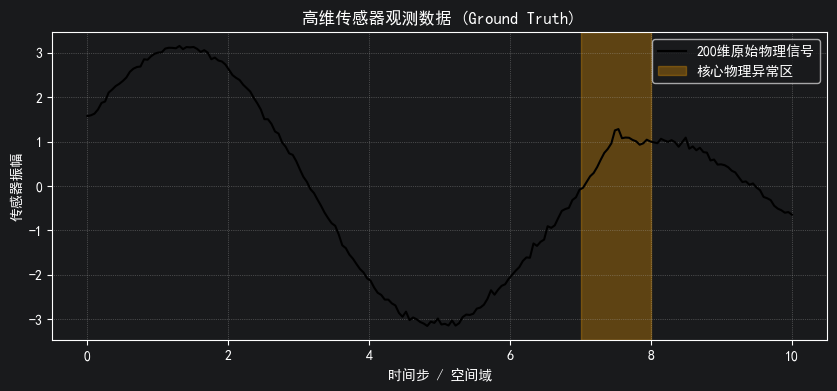

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

print("--- 模块 1：生成高维物理信号 ---")

# 设置全局中文字体与随机种子
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
torch.manual_seed(42)
np.random.seed(42)

time_steps = 200  # 数据的特征维度 N = 200
t = np.linspace(0, 10, time_steps)

def generate_physical_signals(num_samples):
    signals = []
    for _ in range(num_samples):
        # 1. 宏观环境背景：方差极大，极易引起误差函数的关注
        macro_background = 2.0 * np.sin(t) + 1.5 * np.cos(0.5 * t)

        # 2. 核心物理特征：在 t=7.5 处的微弱脉冲（例如微小裂纹的声发射）
        critical_anomaly = 0.5 * np.exp(-((t - 7.5)**2) / 0.05)

        # 3. 传感器白噪声
        noise = np.random.normal(0, 0.05, time_steps)

        signal = macro_background + critical_anomaly + noise
        signals.append(signal)
    return torch.tensor(np.array(signals), dtype=torch.float32)

# 生成 1000 条训练数据与 1 条测试数据
X_train = generate_physical_signals(1000)
X_test = generate_physical_signals(1)

# 可视化展示高维原始数据
plt.figure(figsize=(10, 4))
plt.plot(t, X_test[0].numpy(), label='200维原始物理信号', color='black')
plt.axvspan(7.0, 8.0, color='orange', alpha=0.3, label='核心物理异常区')
plt.title("高维传感器观测数据 (Ground Truth)")
plt.xlabel("时间步 / 空间域")
plt.ylabel("传感器振幅")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## 第二部分：自动编码器 (Autoencoder) 的对称架构

自动编码器（AE）是一种无监督学习（Unsupervised Learning）架构，其核心目标是学习高维数据的有效低维表征。它由两个对称的非线性网络组成：

### 1. 编码器 (Encoder) —— 信息的压缩与降维
编码器网络 $f_\phi(\cdot)$ 负责将高维输入 $x$ 映射为低维潜在向量 $z$：
$$z = f_\phi(x)$$
这一步强行制造了一个**信息瓶颈（Information Bottleneck）**，迫使网络放弃记录所有细节，只保留对重构数据最具决定性的核心特征。

### 2. 解码器 (Decoder) —— 空间的重构与升维
解码器网络 $g_\theta(\cdot)$ 接收低维向量 $z$，试图将其还原为原始维度的高维数据 $\hat{x}$：
$$\hat{x} = g_\theta(z)$$

### 3. 优化目标 (重建误差)
AE 没有任何外部标签（Label），它的目标就是“复刻自己”。其损失函数通常为输入与输出之间的均方误差（MSE）：
$$\mathcal{L}(\theta, \phi) = \frac{1}{M} \sum_{i=1}^{M} ||x_i - g_\theta(f_\phi(x_i))||^2$$

**【代码验证】**：我们将构建一个将 200 维信号极限压缩至 4 维，再重新解码回 200 维的自动编码器，并执行优化训练。

In [4]:
print("--- 模块 2：构建并训练自动编码器 ---")

class ScientificAutoencoder(nn.Module):
    def __init__(self, input_dim=200, latent_dim=4):
        super().__init__()
        # 编码器：强行制造信息瓶颈，降维至 4 维
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 16),
            nn.ReLU(),
            nn.Linear(16, latent_dim)
            # nn.linear(200, 4)
        )

        # 解码器：从 4 维重构回 200 维
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        x_reconstructed = self.decoder(z)
        return x_reconstructed

model = ScientificAutoencoder(input_dim=time_steps, latent_dim=4)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

epochs = 200
print("开始训练自动编码器 (观察 MSE Loss 下降)...")
for epoch in range(epochs):
    optimizer.zero_grad()
    # 无监督学习：直接拿输入数据自己对比自己
    X_reconstructed = model(X_train)
    loss = criterion(X_reconstructed, X_train)
    # loss = critertion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 40 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], 全局重构 MSE Loss: {loss.item():.4f}")
print("训练完成！模型已能够实现极低的重构误差。")

--- 模块 2：构建并训练自动编码器 ---


NameError: name 'time_steps' is not defined

## 第三部分：物理认知的反思 —— 为什么低重构误差 $\neq$ 保留了物理信息？

这是科学机器学习（Scientific ML）与传统计算机视觉最大的分水岭。

在工程实践中，模型往往能将 MSE Loss 降到极低，重构出的信号看起来与原始信号几乎完全一致。**但这并不意味着潜在空间 $Z$ 提取到了正确的物理规律。**

**理论痛点剖析：**
1. **MSE 的统计学短视**：均方误差是一个纯粹的统计学指标。在优化过程中，网络会绝对优先去拟合那些**方差极大、能量极高**的背景宏观特征，以求快速降低整体 Loss。
2. **物理关键特征的边缘化**：决定系统核心状态的物理特征（如极细的吸收线、高频微小异常振幅），其在整体空间中的能量占比往往极低。
3. **模型的“合理偷懒”**：由于信息瓶颈的存在，AE 的带宽有限。为了最小化全局 MSE，模型会主动**将这些低能量但极其重要的物理特征视为“噪声”而丢弃**。

**【代码验证】**：我们将把之前单独抽离出来的测试集数据输入已经训练好的模型中，对比真实数据与重构数据，揭示这片“物理盲区”。

--- 模块 3：物理诊断与重构对比 ---


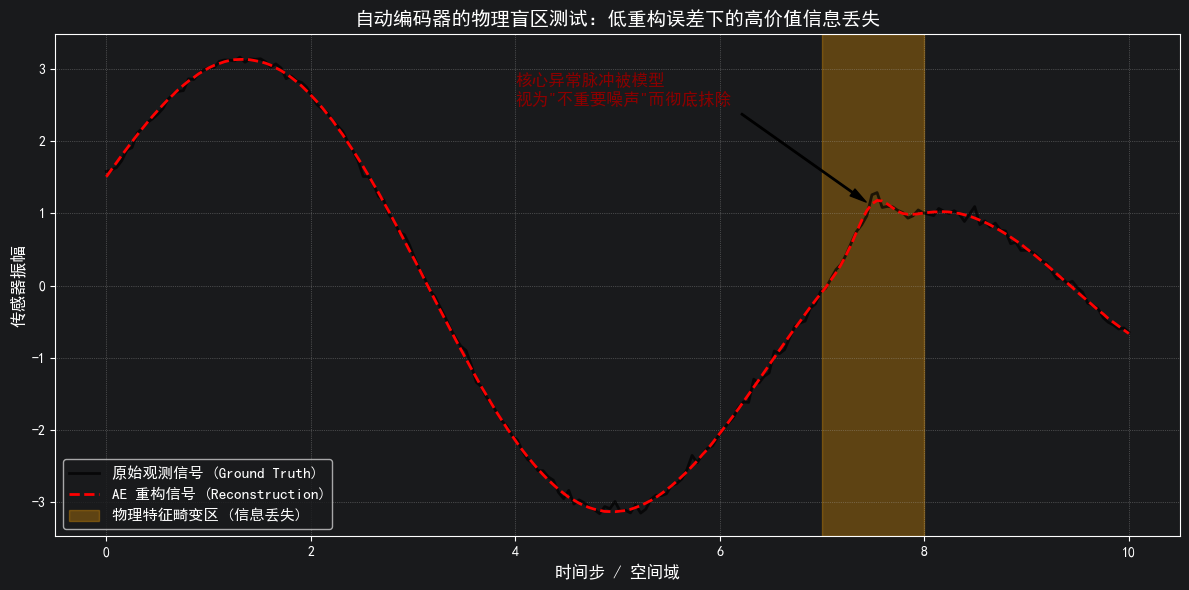

诊断结论：
由于宏观低频正弦背景占据了绝大部分 MSE 权重，它被模型完美重构了。
但在潜在空间的映射过程中，因受制于降维带宽，模型主动抛弃了能量极小的局部异常脉冲。
这证明了在科学计算中，绝对不能盲目迷信统计学上的低误差。


In [3]:
print("--- 模块 3：物理诊断与重构对比 ---")

model.eval()
with torch.no_grad():
    test_signal = X_test[0]
    reconstructed_signal = model(X_test)[0]

plt.figure(figsize=(12, 6))

# 绘制真实数据与模型重构数据
plt.plot(t, test_signal.numpy(), label='原始观测信号 (Ground Truth)', color='black', alpha=0.7, linewidth=2)
plt.plot(t, reconstructed_signal.numpy(), label='AE 重构信号 (Reconstruction)', color='red', linestyle='--', linewidth=2)

# 标注灾难性的信息丢失区域
plt.axvspan(7.0, 8.0, color='orange', alpha=0.3, label='物理特征畸变区 (信息丢失)')
plt.annotate('核心异常脉冲被模型\n视为"不重要噪声"而彻底抹除',
             xy=(7.5, test_signal[150].item() - 0.2),
             xytext=(4, 2.5),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
             fontsize=12, fontweight='bold', color='darkred')

plt.title("自动编码器的物理盲区测试：低重构误差下的高价值信息丢失", fontsize=14)
plt.xlabel("时间步 / 空间域", fontsize=12)
plt.ylabel("传感器振幅", fontsize=12)
plt.legend(loc='lower left', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

print("诊断结论：")
print("由于宏观低频正弦背景占据了绝大部分 MSE 权重，它被模型完美重构了。")
print("但在潜在空间的映射过程中，因受制于降维带宽，模型主动抛弃了能量极小的局部异常脉冲。")
print("这证明了在科学计算中，绝对不能盲目迷信统计学上的低误差。")